In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index())

Total images: 44000
label
0    12800
1    31200
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

train_df, validation_df = train_test_split(
    development_df,
    test_size=15 / 85,
    stratify=development_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}: {len(split_df)} images")
    print(split_df["label"].value_counts().sort_index())


Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                10000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    train_df,
    training=True
)

validation_dataset = create_dataset(
    validation_df
)

test_dataset = create_dataset(
    test_df
)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        float(tf.reduce_min(images)),
        "to",
        float(tf.reduce_max(images))
    )

I0000 00:00:1787582539.918203      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [7]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weight_values[0]),
    1: float(weight_values[1])
}

print("Maximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Class weights:", class_weights)

Maximum epochs: 30
Patience: 5
Learning rate: 0.0001
Batch size: 32
Class weights: {0: 1.71875, 1: 0.7051282051282052}


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        0.05,
        0.05
    )
])

mobilenet_base = (
    tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

mobilenet_base.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

x = mobilenet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="MobileNetV2_Binary"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)

print(
    "MobileNetV2 frozen:",
    not mobilenet_base.trainable
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 2259265
Trainable parameters: 1281
MobileNetV2 frozen: True


Model: "MobileNetV2_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/mobilenetv2_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5367 - loss: 0.7312
Epoch 1: val_loss improved from None to 0.60238, saving model to /kaggle/working/mobilenetv2_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 99s 95ms/step - accuracy: 0.5886 - loss: 0.6810 - val_accuracy: 0.6764 - val_loss: 0.6024 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6730 - loss: 0.6044
Epoch 2: val_loss improved from 0.60238 to 0.59615, saving model to /kaggle/working/mobilenetv2_best.keras

Epoch 2: finished saving model to /kaggle/working/mobilenetv2_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.6844 - loss: 0.5910 - val_accuracy: 0.6830 - val_loss: 0.5962 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7095 - loss: 0.5642
Epoch 3: val_loss did not improve from 0.59615
963/963 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/s

In [10]:
history_df = pd.DataFrame(
    history.history
)

history_df.index = range(
    1,
    len(history_df) + 1
)

history_df.index.name = "Epoch"

best_epoch = history_df[
    "val_loss"
].idxmin()

display(
    history_df[
        [
            "loss",
            "accuracy",
            "val_loss",
            "val_accuracy"
        ]
    ].rename(
        columns={
            "loss": "Training Loss",
            "accuracy": "Training Accuracy",
            "val_loss": "Validation Loss",
            "val_accuracy": "Validation Accuracy"
        }
    ).round(4)
)

print("Best epoch:", best_epoch)

,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy
Epoch,,,,
1,0.6810,0.5886,0.6024,0.6764
2,0.5910,0.6844,0.5962,0.6830
3,0.5601,0.7156,0.6291,0.6574
4,0.5396,0.7321,0.6466,0.6505
5,0.5324,0.7400,0.6022,0.6835
6,0.5243,0.7465,0.5931,0.6911
7,0.5184,0.7498,0.6040,0.6836
8,0.5179,0.7501,0.6032,0.6858
9,0.5129,0.7536,0.5924,0.6942


Best epoch: 9


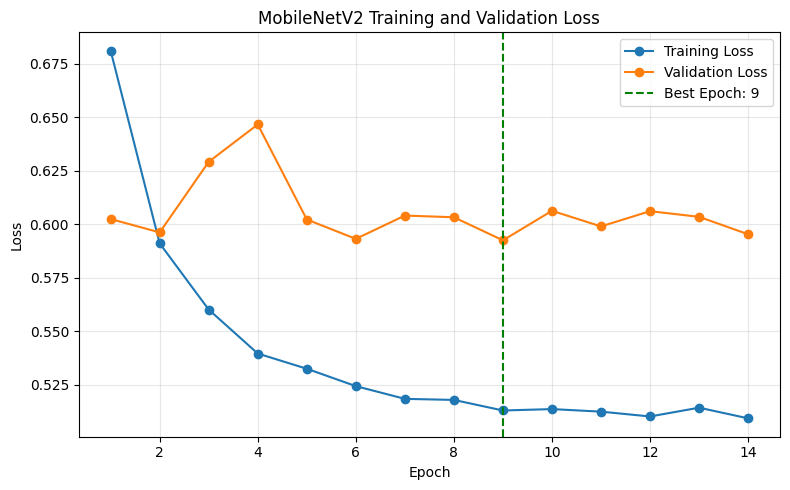

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title(
    "MobileNetV2 Training and Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

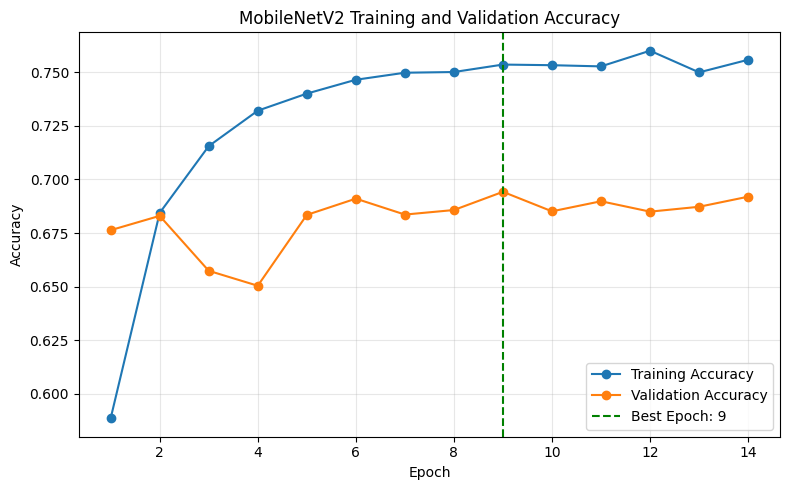

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title(
    "MobileNetV2 Training and Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6977 - loss: 0.5837
Test Loss: 0.5837
Test Accuracy: 0.6977


In [14]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df[
    "label"
].to_numpy()

print("Test images:", len(true_labels))
print("Predictions:", len(test_predictions))

207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step
Test images: 6600
Predictions: 6600


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_precision = precision_score(
    true_labels,
    test_predictions
)

test_recall = recall_score(
    true_labels,
    test_predictions
)

test_f1 = f1_score(
    true_labels,
    test_predictions
)

test_auc = roc_auc_score(
    true_labels,
    test_probabilities
)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1-score:", round(test_f1, 4))
print("ROC-AUC:", round(test_auc, 4))

Test Loss: 0.5837
Accuracy: 0.6977
Precision: 0.9271
Recall: 0.6226
F1-score: 0.745
ROC-AUC: 0.8531


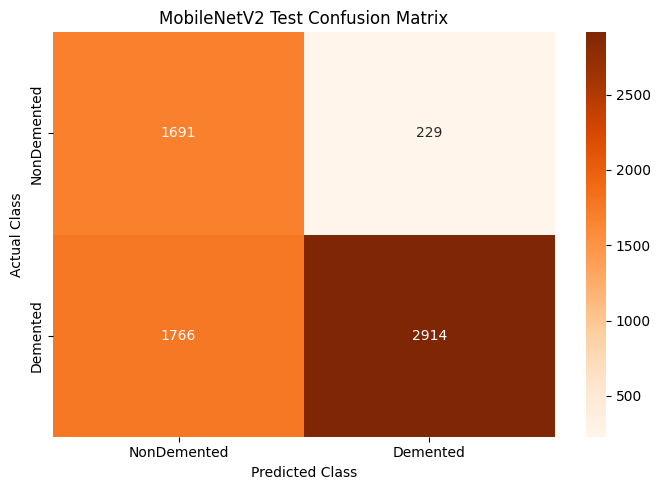

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=[
        "NonDemented",
        "Demented"
    ],
    yticklabels=[
        "NonDemented",
        "Demented"
    ]
)

plt.title(
    "MobileNetV2 Test Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

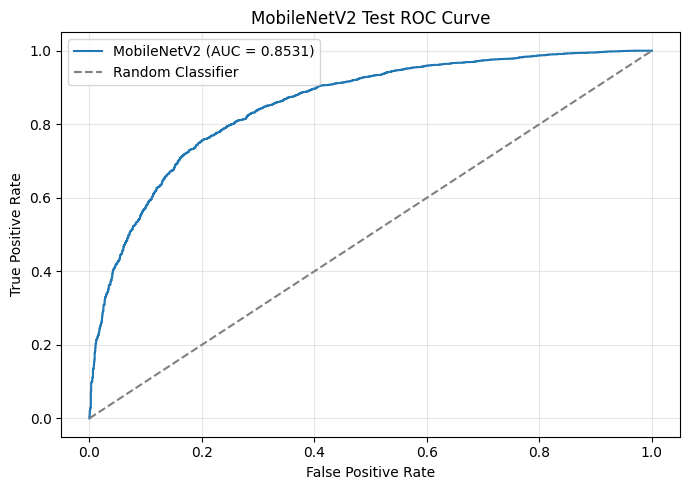

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=(
        f"MobileNetV2 "
        f"(AUC = {test_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title(
    "MobileNetV2 Test ROC Curve"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

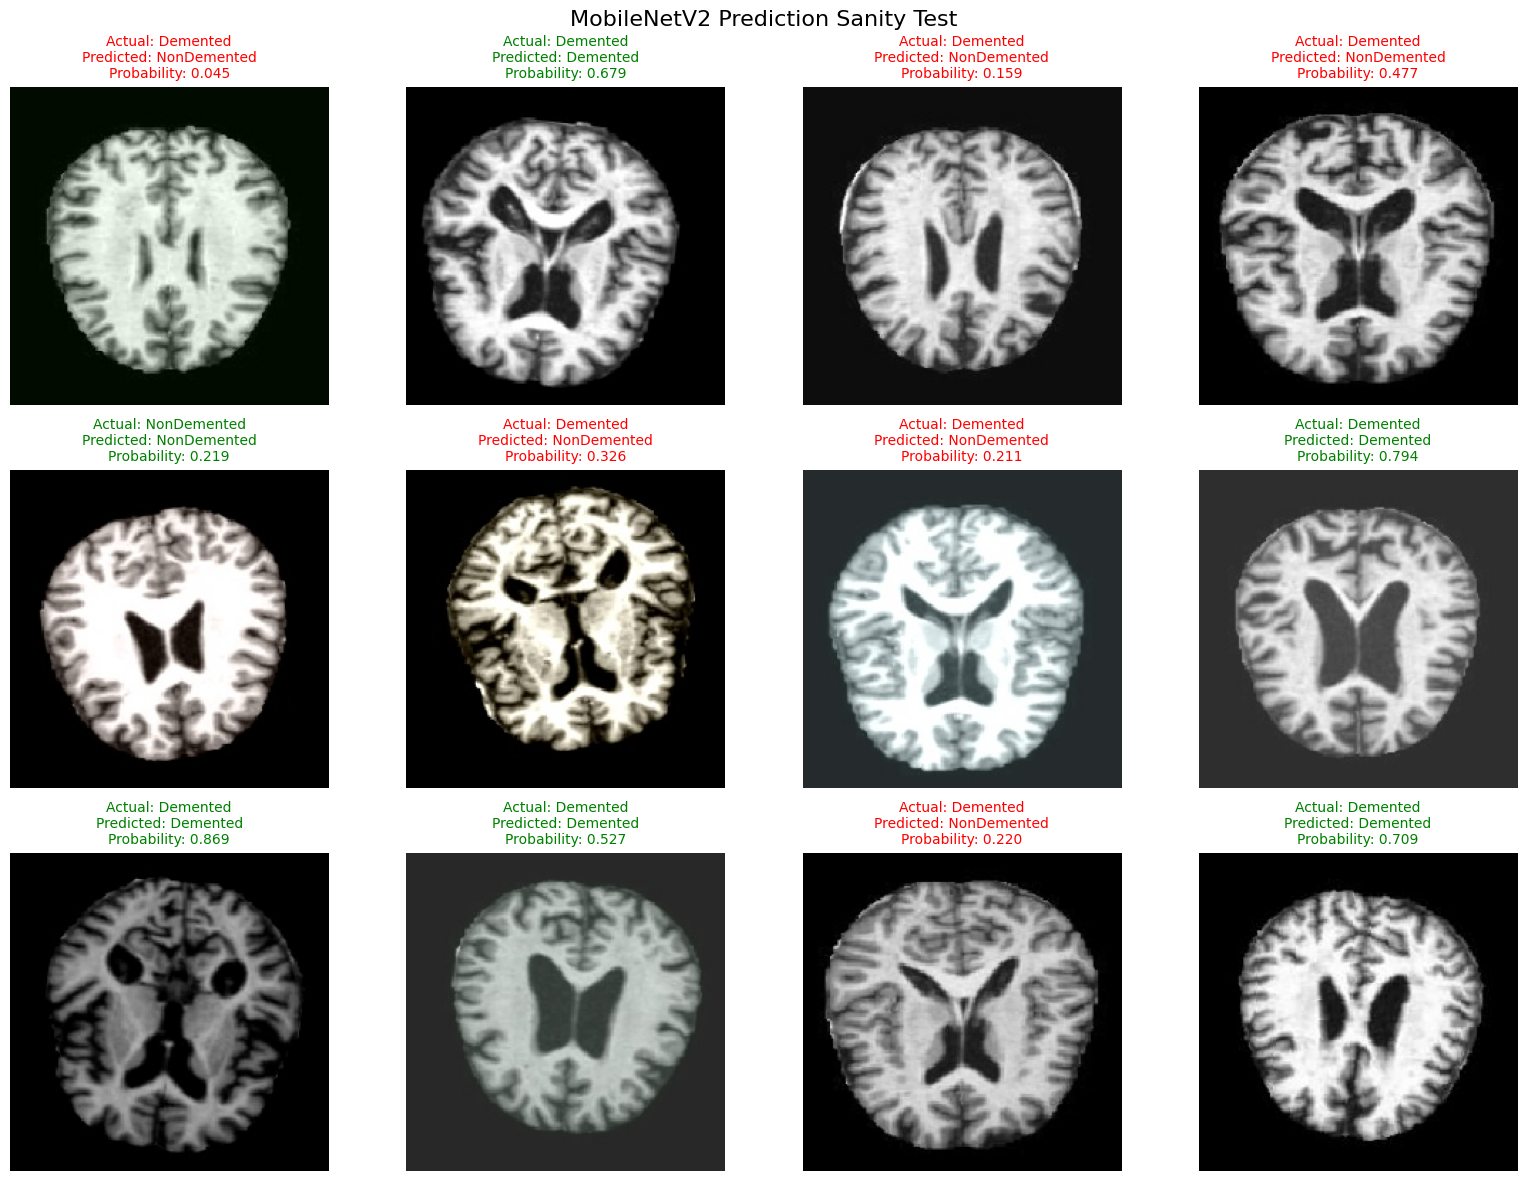

In [18]:
sample_indices = np.random.default_rng(
    SEED
).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(
    sample_indices,
    start=1
):
    image = tf.keras.utils.load_img(
        test_df.iloc[index]["filepath"],
        target_size=IMG_SIZE
    )

    actual = true_labels[index]
    predicted = test_predictions[index]
    probability = test_probabilities[index]

    actual_name = (
        "Demented"
        if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented"
        if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green"
        if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "MobileNetV2 Prediction Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
results_df = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Cross-Validation": ["No"],
    "Best Epoch": [best_epoch],
    "Epochs Trained": [len(history_df)],
    "Test Loss": [test_loss],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "F1-score": [test_f1],
    "ROC-AUC": [test_auc]
})

history_export_df = (
    history_df
    .reset_index()
)

results_df.to_csv(
    "/kaggle/working/mobilenetv2_results.csv",
    index=False
)

history_export_df.to_csv(
    "/kaggle/working/mobilenetv2_training_history.csv",
    index=False
)

display(
    results_df.round(4)
)

print(
    "MobileNetV2 result files saved."
)

,Model,Cross-Validation,Best Epoch,Epochs Trained,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,MobileNetV2,No,9,14,0.5837,0.6977,0.9271,0.6226,0.745,0.8531


MobileNetV2 result files saved.
